In [2]:
# Setup & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Load data
import sys
sys.path.append(r'D:\Vaidehi Study\Regional_Sales_Analysis\04_scripts')
from config import DB_CONFIG

engine = create_engine(f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")
df = pd.read_sql("SELECT * FROM v_master_sales_report", con=engine)

print("✅ Data loaded for regional analysis")

✅ Data loaded for regional analysis


In [11]:
#Detailed State Analysis
# WHAT: Deep dive into regional performance
# WHY: Understand each state's contribution

print("=" * 80)
print("DETAILED STATE ANALYSIS")
print("=" * 80)

state_analysis = df.groupby('State').agg(
    Revenue_Sum=('Revenue', 'sum'),
    Revenue_Count=('Revenue', 'count'),
    Revenue_Mean=('Revenue', 'mean'),
    Order_Count=('OrderNumber', 'count')
).round(2)

state_analysis.columns = ['Total_Revenue', 'Order_Count', 'Avg_Order_Value', 'Unique_Orders']
state_analysis = state_analysis.sort_values('Total_Revenue', ascending=False)

print(state_analysis)

# Export
state_analysis.to_csv(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\state_summary.csv')
print("\n✅ State summary exported")

DETAILED STATE ANALYSIS
                      Total_Revenue  Order_Count  Avg_Order_Value  \
State                                                               
California               12517562.9        12000          1043.13   
Illinois                  5764703.0         5682          1014.56   
Florida                   4802339.9         4601          1043.76   
Texas                     4366215.1         4289          1018.00   
Indiana                   2981793.3         2830          1053.64   
New York                  2794583.7         2829           987.83   
Connecticut               2438383.4         2264          1077.02   
New Jersey                2437085.3         2378          1024.85   
Michigan                  2049630.6         2039          1005.21   
Massachusetts             1793923.1         1768          1014.66   
Washington                1661940.1         1536          1081.99   
Minnesota                 1552415.9         1319          1176.96   
Colorado  

TOP 20 CITIES BY REVENUE
 1. Springfield          $     358,925.60
 2. Jackson              $     283,049.50
 3. Bloomington          $     260,381.60
 4. Lakewood             $     249,306.30
 5. Wayne                $     247,163.70
 6. Columbia             $     220,799.80
 7. Plymouth             $     216,026.80
 8. Albany               $     212,607.10
 9. Bellevue             $     205,960.70
10. Fairfield            $     196,982.90
11. Westminster          $     192,459.70
12. Brookhaven           $     188,824.00
13. Warren               $     188,408.30
14. Lafayette            $     183,136.20
15. Portland             $     181,171.50
16. Jacksonville         $     179,955.40
17. Perry                $     178,639.50
18. Glendale             $     174,730.30
19. Pasadena             $     174,451.30
20. Concord              $     174,425.30


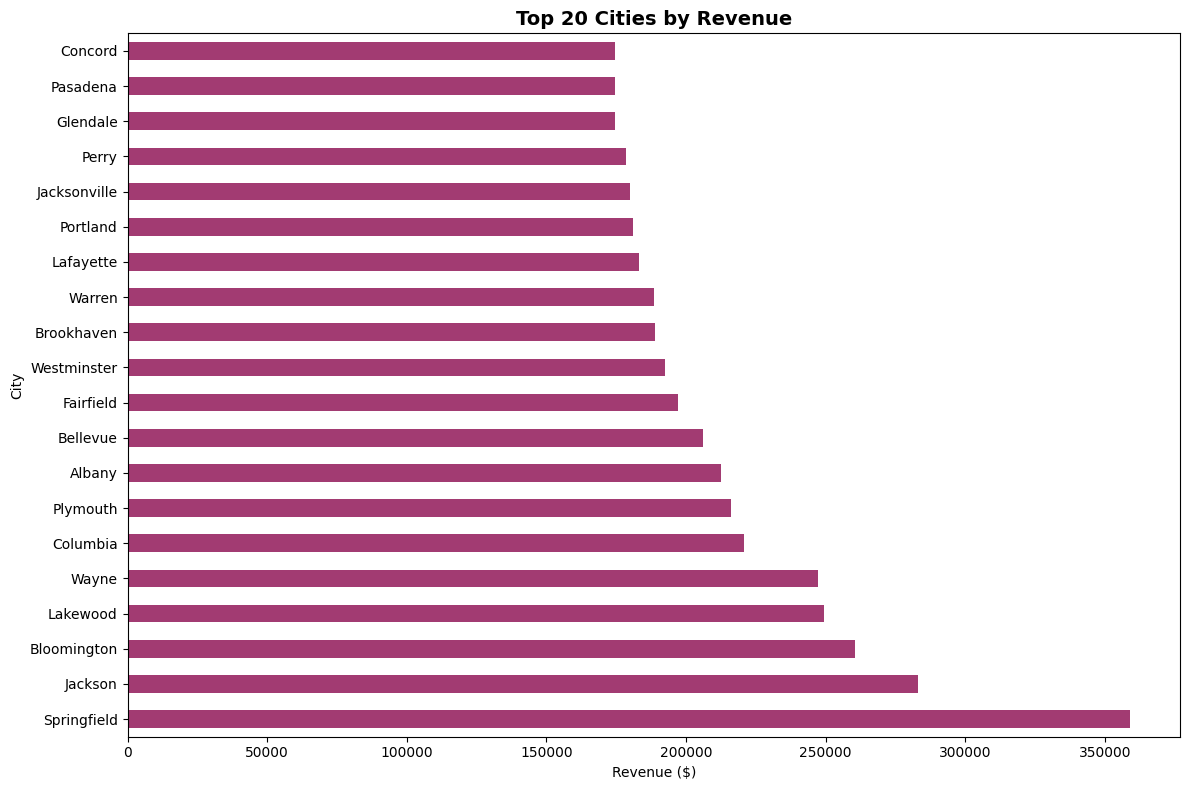

In [13]:
# Top Cities by Revenue
# WHAT: Which cities perform best?
# WHY: Micro-level regional insights

print("=" * 80)
print("TOP 20 CITIES BY REVENUE")
print("=" * 80)

city_revenue = df.groupby('City')['Revenue'].sum().sort_values(ascending=False).head(20)

for i, (city, revenue) in enumerate(city_revenue.items(), 1):
    print(f"{i:2d}. {city:20s} ${revenue:>15,.2f}")

# Chart
plt.figure(figsize=(12, 8))
city_revenue.plot(kind='barh', color='#A23B72')
plt.title('Top 20 Cities by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('City')
plt.tight_layout()
plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\04_top_cities.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#  Product Performance by Top State
# WHAT: Which products sell best in each top state?
# WHY: Understand regional product preferences

print("=" * 80)
print("PRODUCT PERFORMANCE IN TOP 5 STATES")
print("=" * 80)

#Identifying Top 5 states
top_states = df.groupby('State')['Revenue'].sum().sort_values(ascending=False).head(5).index

#Looping through each state
for state in top_states:
    print(f"\n{state}:")
    #Finding top 5 products by State
    state_products = df[df['State'] == state].groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5)
        #Displaying results
        for product, revenue in state_products.items():
            print(f"  • {product:20s} ${revenue:>12,.2f}")

PRODUCT PERFORMANCE IN TOP 5 STATES

California:
  • Product 25           $1,023,166.40
  • Product 26           $1,000,047.80
  • Product 13           $  864,497.90
  • Product 15           $  779,475.00
  • Product 5            $  732,051.60

Illinois:
  • Product 25           $  585,672.00
  • Product 26           $  542,513.10
  • Product 5            $  357,857.60
  • Product 15           $  354,966.90
  • Product 13           $  300,426.20

Florida:
  • Product 25           $  373,218.70
  • Product 5            $  367,927.90
  • Product 26           $  354,358.40
  • Product 2            $  329,690.20
  • Product 14           $  320,873.70

Texas:
  • Product 26           $  358,478.10
  • Product 15           $  335,053.60
  • Product 25           $  330,759.60
  • Product 5            $  309,931.80
  • Product 14           $  274,048.10

Indiana:
  • Product 26           $  257,693.60
  • Product 25           $  248,413.30
  • Product 15           $  190,811.30
  • Product 2  